# 00 — Smoke test del pipeline v2 sobre las galaxias piloto

Verificación rápida de los productos generados para `TNG50-87-155298-0-127` y `TNG50-87-192324-0-127`.

Secciones: (1) features de Fase A y ε vs catálogo, (2) alineación 3D→2D vs pyPipe3D, (3) tensores `Y_int` y máscara, (4) QA reports, (5) consistencia espacial P(bulbo) vs P(disco) por radio.

In [1]:
from pathlib import Path
import json
import numpy as np
import h5py
import matplotlib.pyplot as plt
from aperturenet_labels.io import manifest, catalogs, mangia_reader
from aperturenet_labels.phase_a import extractor, classifier
from aperturenet_labels.phase_c.packer import validate_dataset_entry

DATA = Path('../../data').resolve()
rows = manifest.pilot_manifest(DATA)
CLASSES = ['bulge', 'disk', 'bar', 'arm', 'halo']
print([r.canonical_id for r in rows])

['TNG50-87-155298-0-127', 'TNG50-87-192324-0-127']


## 1. Fase A — distribución de ε y comparación con catálogos

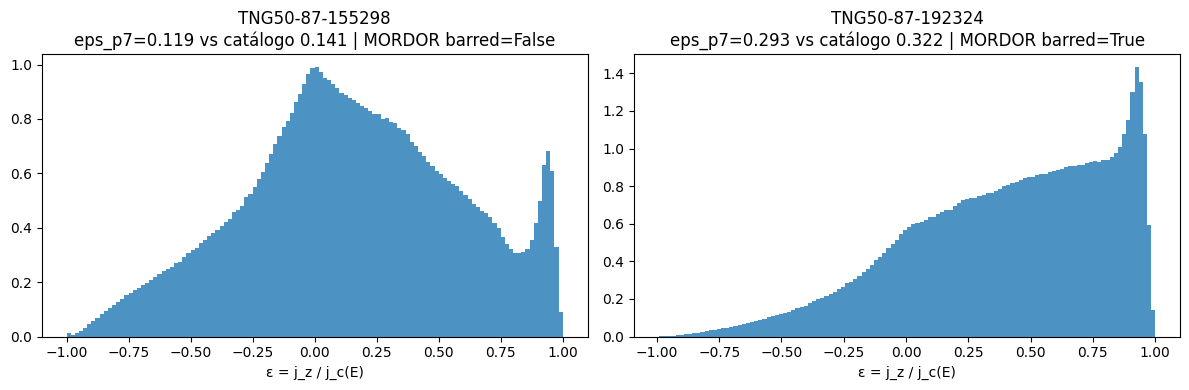

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, r in zip(axes, rows):
    gal = manifest.galaxy_id(r.snapshot, r.subhalo_id)
    feats = extractor.load_particle_features(
        DATA / 'intermediate/phase_a' / gal / 'particle_features.h5')
    circs = catalogs.load_stellar_circs(DATA / 'stellar_circs.hdf5', r.snapshot, r.subhalo_id)
    mordor = catalogs.load_morphology_targets(
        DATA / 'morphs_kinematic_bars.hdf5', r.snapshot, r.subhalo_id)
    ax.hist(feats['epsilon'], bins=120, density=True, alpha=0.8)
    p7 = feats['quality']['epsilon_p7_fraction']
    ax.set_title(f"{gal}\n"
                 f"eps_p7={p7:.3f} vs catálogo {circs['CircAbove07Frac']:.3f} | "
                 f"MORDOR barred={mordor.barred}")
    ax.set_xlabel('ε = j_z / j_c(E)')
plt.tight_layout()

## 2. Alineación 3D→2D contra el mapa de masa de pyPipe3D (gate del spec 20)

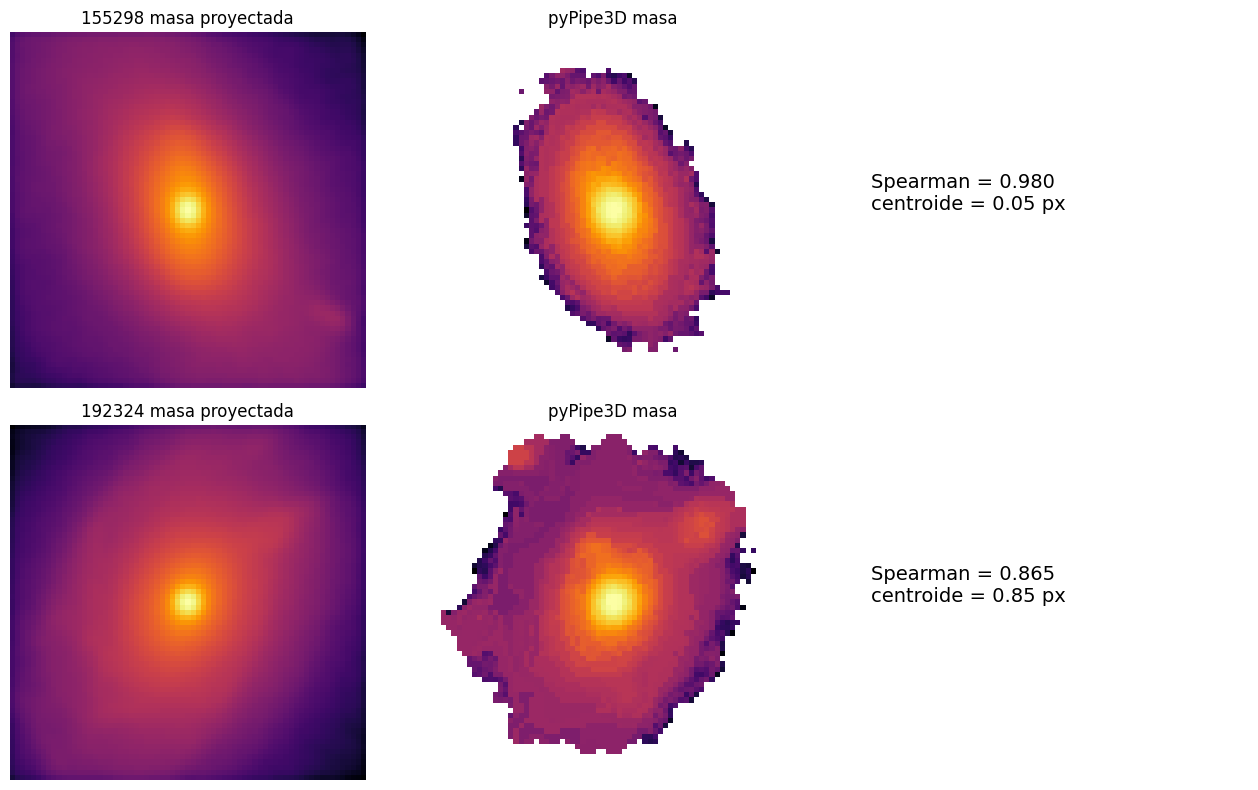

In [3]:
from scipy.stats import spearmanr
from scipy.ndimage import center_of_mass
from aperturenet_labels.io import tng_reader, units
from aperturenet_labels.core.geometry import view_vector_from_index, deposit_to_grid
from aperturenet_labels.phase_b.label_projection import mangia_raster_coords

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for i, r in enumerate(rows):
    truth = units.convert_truth_units(tng_reader.load_cutout_truth(
        r.cutout_path, r.subhalo_json_path, r.cutout_phase2_path))
    geom = mangia_reader.load_cube_geometry(r.cube_path)
    p3d = mangia_reader.load_pipe3d_maps(r.pipe3d_maps_path)['mass_density']
    centered = truth.stellar_pos - truth.subhalo_pos[None, :]
    u, v, _ = mangia_raster_coords(centered, view_vector_from_index(r.view, r.repeat_count))
    grid = deposit_to_grid(v, u, truth.stellar_mass, geom.shape,
                           geom.pixel_scale_kpc, sigma_pixels=geom.psf_sigma_pixels)
    good = np.isfinite(p3d) & (p3d != 0)
    m = good & (p3d > np.percentile(p3d[good], 30)) & (grid > 0)
    rho = spearmanr(np.log10(grid[m]), p3d[m]).statistic
    c1 = center_of_mass(grid / grid.sum())
    c2 = center_of_mass(np.where(good, 10 ** np.clip(p3d, -5, 15), 0.0))
    shift = float(np.hypot(c1[0] - c2[0], c1[1] - c2[1]))
    axes[i, 0].imshow(np.log10(np.clip(grid, 1, None)), origin='lower', cmap='inferno')
    axes[i, 0].set_title(f'{r.subhalo_id} masa proyectada')
    axes[i, 1].imshow(np.where(good, p3d, np.nan), origin='lower', cmap='inferno')
    axes[i, 1].set_title('pyPipe3D masa')
    axes[i, 2].axis('off')
    axes[i, 2].text(0.1, 0.5, f'Spearman = {rho:.3f}\ncentroide = {shift:.2f} px',
                    fontsize=14)
    assert shift < 1.0 and rho > 0.8
for ax in axes[:, :2].flat:
    ax.axis('off')
plt.tight_layout()

## 3. Tensores de pseudo-etiquetas `Y_int` y máscara `M_valid`

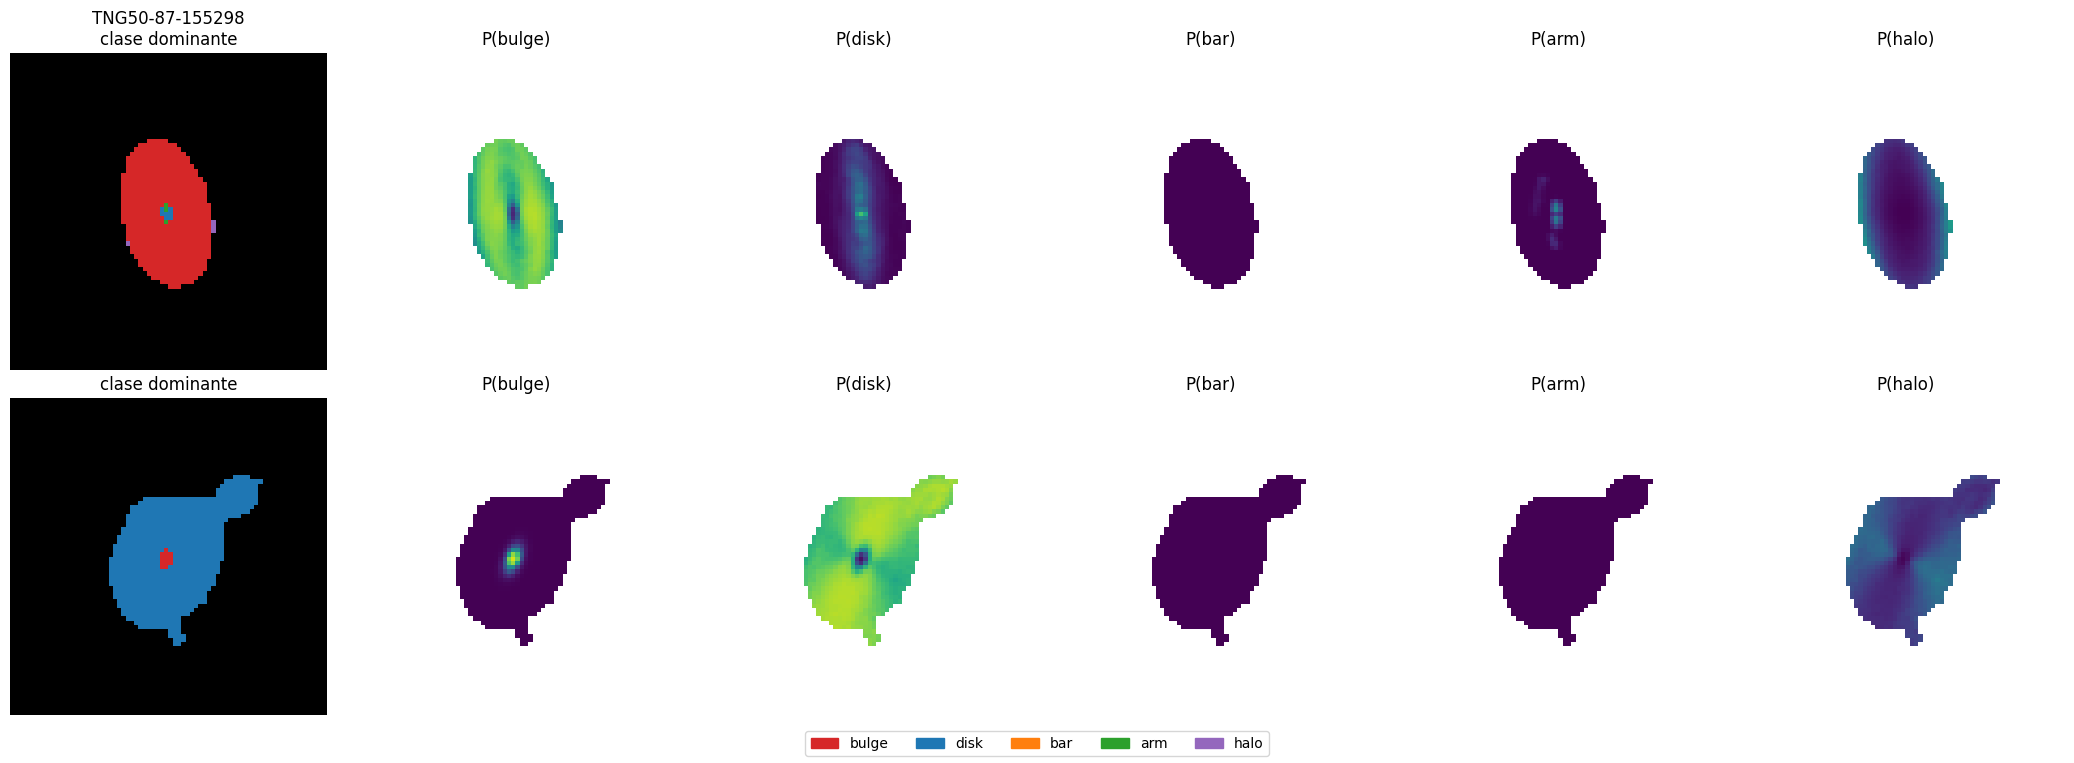

In [4]:
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']
fig, axes = plt.subplots(2, 6, figsize=(21, 7.5))
for i, r in enumerate(rows):
    gal = manifest.galaxy_id(r.snapshot, r.subhalo_id)
    with h5py.File(DATA / 'output/dataset_entries' / f'{gal}_v0.h5') as f:
        Y = f['labels/Y_int_mass'][:]
        M = f['masks/M_valid'][:]
    am = np.where(M & (Y.sum(-1) > 0), Y.argmax(-1), -1)
    axes[i, 0].imshow(am, origin='lower', cmap=ListedColormap(['black'] + colors),
                      vmin=-1, vmax=4)
    axes[i, 0].set_title(f'{gal}\nclase dominante')
    for c in range(5):
        axes[i, 1 + c].imshow(np.where(M, Y[:, :, c], np.nan), origin='lower',
                              vmin=0, vmax=1)
        axes[i, 1 + c].set_title(f'P({CLASSES[c]})')
for ax in axes.flat:
    ax.axis('off')
fig.legend(handles=[mpatches.Patch(color=colors[c], label=CLASSES[c]) for c in range(5)],
           loc='lower center', ncol=5)
plt.tight_layout(rect=[0, 0.04, 1, 1])

## 4. QA reports y roundtrip del HDF5 final

In [5]:
for r in rows:
    gal = manifest.galaxy_id(r.snapshot, r.subhalo_id)
    qa = json.loads((DATA / 'output/qa_reports' / f'{gal}_v0.json').read_text())
    entry = validate_dataset_entry(DATA / 'output/dataset_entries' / f'{gal}_v0.h5')
    print(gal)
    print('  status:', qa['status'], '| flags:', qa['flags'])
    print('  conservación de masa:', f"{qa['mass_conservation_error']:.2e}")
    print('  fracciones (en M_valid):',
          {k: round(v, 3) for k, v in qa['fractions_recovered'].items()})
    print('  roundtrip OK, n_valid =', entry['n_valid'])

TNG50-87-155298
  status: warning | flags: ['fraction_dev_bulge', 'fraction_dev_disk', 'fraction_dev_other', 'low_validity']
  conservación de masa: 9.51e-06
  fracciones (en M_valid): {'bulge': 0.532, 'disk': 0.305, 'bar': 0.0, 'arm': 0.116, 'halo': 0.047}
  roundtrip OK, n_valid = 584
TNG50-87-192324
  status: warning | flags: ['fraction_dev_bulge', 'fraction_dev_disk', 'fraction_dev_other', 'low_validity']
  conservación de masa: 4.40e-06
  fracciones (en M_valid): {'bulge': 0.364, 'disk': 0.517, 'bar': 0.0, 'arm': 0.0, 'halo': 0.119}
  roundtrip OK, n_valid = 770


## 5. Consistencia espacial: P(bulbo) vs P(disco) por radio

Chequea si, cerca del centro de cada galaxia, `P(disco)` supera a `P(bulbo)` (síntoma del GMM en galaxias sin disco real, ver ADR-001 §3).

TNG50-87-155298: spaxels centrales (r<3px) = 32
  P(disco) > P(bulbo): 10/32 (31%)
  argmax == disco:     7/32 (22%)
TNG50-87-192324: spaxels centrales (r<3px) = 32
  P(disco) > P(bulbo): 20/32 (62%)
  argmax == disco:     20/32 (62%)


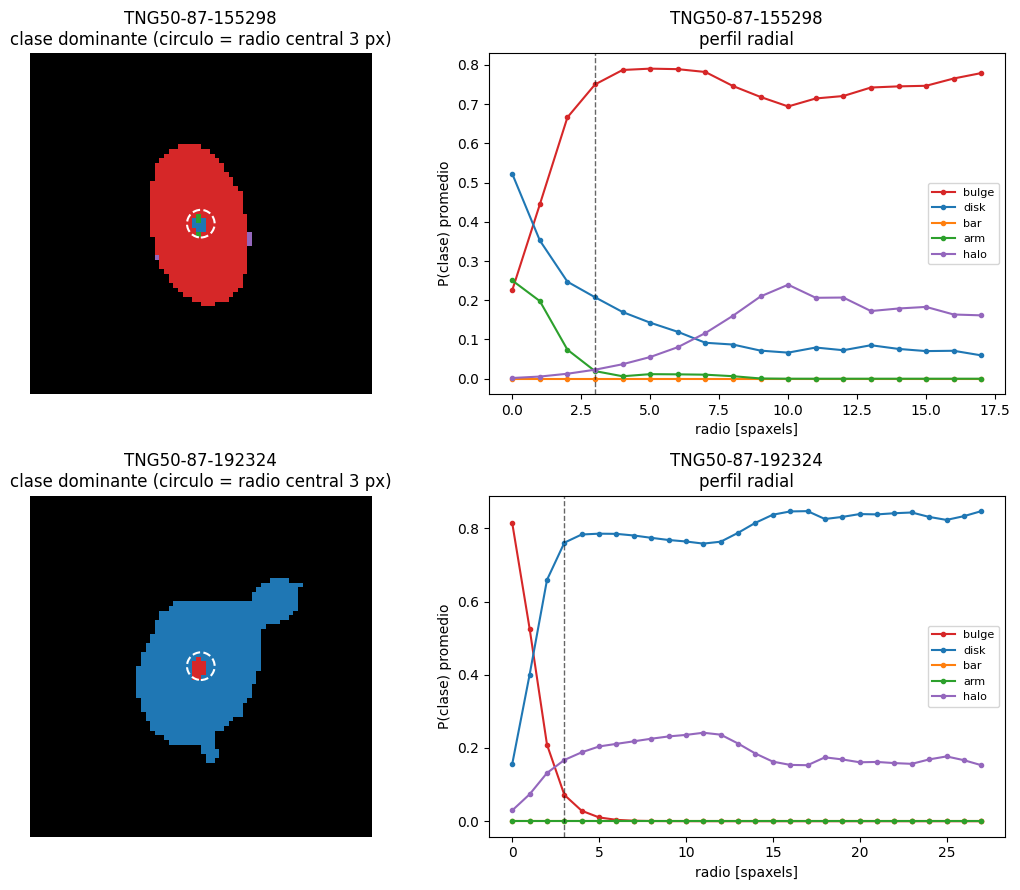

In [6]:
CENTER_R_PX = 3.0  # radio "central" de referencia para el resumen cuantitativo

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for i, r in enumerate(rows):
    gal = manifest.galaxy_id(r.snapshot, r.subhalo_id)
    with h5py.File(DATA / 'output/dataset_entries' / f'{gal}_v0.h5') as f:
        Y = f['labels/Y_int_mass'][:]
        M = f['masks/M_valid'][:]
    h, w, _ = Y.shape
    cy, cx = h / 2 - 0.5, w / 2 - 0.5
    yy, xx = np.indices((h, w))
    r_px = np.hypot(yy - cy, xx - cx)

    valid = M & (Y.sum(-1) > 0)
    am = np.where(valid, Y.argmax(-1), -1)

    ax_map = axes[i, 0]
    ax_map.imshow(am, origin='lower', cmap=ListedColormap(['black'] + colors), vmin=-1, vmax=4)
    ax_map.add_patch(mpatches.Circle((cx, cy), CENTER_R_PX, fill=False, ec='white', lw=1.5, ls='--'))
    ax_map.set_title(f'{gal}\nclase dominante (circulo = radio central {CENTER_R_PX:.0f} px)')
    ax_map.axis('off')

    r_max = r_px[valid].max()
    bins = np.arange(0, r_max + 1, 1.0)
    bin_idx = np.digitize(r_px[valid], bins) - 1
    ax_prof = axes[i, 1]
    for c in range(5):
        pc = Y[:, :, c][valid]
        means = np.array([pc[bin_idx == b].mean() if np.any(bin_idx == b) else np.nan
                          for b in range(len(bins))])
        ax_prof.plot(bins, means, color=colors[c], label=CLASSES[c], marker='o', ms=3)
    ax_prof.axvline(CENTER_R_PX, color='k', ls='--', lw=1, alpha=0.6)
    ax_prof.set_xlabel('radio [spaxels]')
    ax_prof.set_ylabel('P(clase) promedio')
    ax_prof.set_title(f'{gal}\nperfil radial')
    ax_prof.legend(fontsize=8)

    central = valid & (r_px < CENTER_R_PX)
    n_central = int(central.sum())
    p_bulge = Y[:, :, 0]
    p_disk = Y[:, :, 1]
    n_disk_beats_bulge = int((p_disk[central] > p_bulge[central]).sum())
    n_argmax_disk = int((am[central] == 1).sum())
    print(f'{gal}: spaxels centrales (r<{CENTER_R_PX:.0f}px) = {n_central}')
    if n_central > 0:
        print(f'  P(disco) > P(bulbo): {n_disk_beats_bulge}/{n_central} '
              f'({100 * n_disk_beats_bulge / n_central:.0f}%)')
        print(f'  argmax == disco:     {n_argmax_disk}/{n_central} '
              f'({100 * n_argmax_disk / n_central:.0f}%)')
plt.tight_layout()
